LOADING DATA
Loaded 1618 rows


,Missing,N,Mean,Min,Median,Max
OCD_XRAY,13,1605,0.50,0,1,1
Surgery Certificate,0,1618,0.27,0,0,1
Sales Price,0,1618,"236,640.91","25,000","130,000","4,050,000"
Dam BLUP,347,1271,106.72,85,107,125
American Stakes,0,1618,0.06,0,0,1
Sire Stud Fee,0,1618,"95,076.27","14,400","80,000","500,000"
Sire BLUP,239,1379,118.51,96,119,129
Dam Sire BLUP,67,1551,110.50,88,110,127
Year,0,1618,"2,023.96","2,023","2,024","2,025"
Sibling Earnings,475,1143,"1,524,578.11",0,"465,600","29,750,678"



Table 7b: Categorical Variables


,Missing,Unique,Most frequent,Count
Variable,,,,
Gender,0,2,H,865
Sire,0,126,Readly Express,140
Dam,0,1198,Livi Nike H.M.,3
Dams_Sire,0,187,Muscle Hill (US),146
Breeder,0,370,Menhammar Stuteri AB,155


BREEDER - SMOOTHED TARGET ENCODING (Leave-One-Out)

[BREEDER STATISTICS]
  Total breeders: 370
  Global mean (log_price): 11.8233

  Breeder count distribution:
    1 horse:     176 breeders (47.6%)
    2-5 horses:  133 breeders
    6-10 horses: 31 breeders
    11+ horses:  30 breeders

[SMOOTHING PARAMETER]
  Global variance:       1.0189
  Avg within-group var:  0.4853
  Empirical Bayes m:     2.10

[APPLYING LEAVE-ONE-OUT ENCODING]
  ✓ Leave-one-out encoding applied
  Note: Each horse's encoding excludes its own price

[ENCODED FEATURE STATISTICS]
  Mean:   11.8558
  Std:    0.4031
  Min:    10.8471
  Max:    13.2050

[CORRELATION WITH log_price]
  Breeder_Encoded (LOO): r = +0.3846

[SHRINKAGE VISUALIZATION]


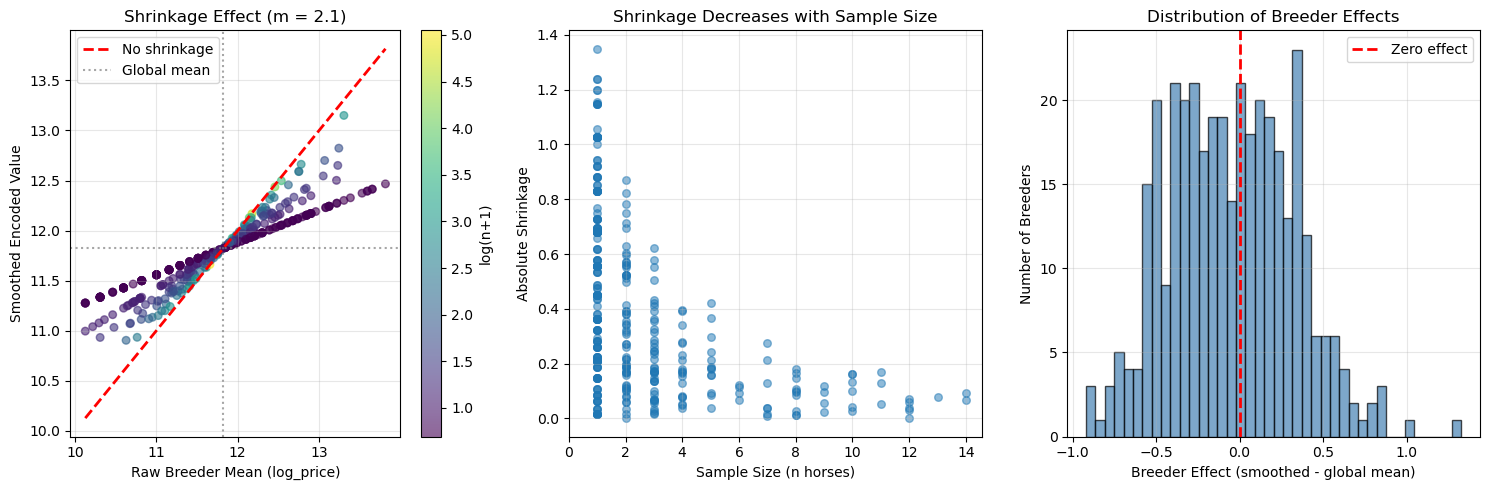


✓ Saved: breeder_encoding_analysis.svg

[TOP 10 BREEDERS (by effect)]
  Breeder                                      n   Raw Mean   Smoothed     Effect
  ---------------------------------------- ----- ---------- ---------- ----------
  Ecurie Diocles AB                           18     13.305     13.150     +1.327
  Courant Inc.                                 5     13.243     12.823     +1.000
  Journey Hästar AB                            5     13.068     12.700     +0.877
  Snogarps Gård AB                            15     12.780     12.662     +0.839
  Equo Estate AB                               3     13.230     12.651     +0.827
  Ecurie Barosso                              10     12.752     12.591     +0.767
  Stal Quattro V.O.F.                         10     12.750     12.589     +0.766
  Pellini Breeding AB                          3     13.051     12.545     +0.722
  Stall Grini A/S                              2     13.214     12.502     +0.678
  Stall Courant AB         

In [11]:
# =========================================================
# CORRELATION ANALYSIS - HORSE AUCTION DATA
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Helper functions
# ---------------------------------------------------------
def find_col(df, candidates):
    """Find column by exact, case-insensitive, or substring match."""
    cols = list(df.columns)
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in cols:
            return cand
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
        for c in cols:
            if cand.lower() in c.lower():
                return c
    return None

def to_numeric_safe(series):
    """Convert series to numeric, handling various formats."""
    return pd.to_numeric(
        series.astype(str)
              .str.replace("\u00a0", "", regex=False)
              .str.replace(" ", "", regex=False)
              .str.replace(",", ".", regex=False),
        errors="coerce"
    )


# ---------------------------------------------------------
# Load data
# ---------------------------------------------------------
print("="*70)
print("LOADING DATA")
print("="*70)

df = pd.read_excel("GAM.xlsx")
df.columns = [c.strip() for c in df.columns]
print(f"Loaded {len(df)} rows")


from IPython.display import display
import pandas as pd

df_clean = df.drop(columns=['Unnamed: 0'], errors='ignore').reset_index() # brings back 'date'

def eda_summary(df: pd.DataFrame) -> pd.DataFrame:
    s = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_%": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    })

    num_cols = df.select_dtypes(include="number").columns
    cat_cols = df.columns.difference(num_cols)

    if len(num_cols) > 0:
        num_stats = df[num_cols].describe().T
        num_stats["median"] = df[num_cols].median(numeric_only=True)
        num_stats = num_stats.rename(columns={"count": "count_non_missing"})[
            ["count_non_missing", "mean", "std", "min", "median", "max"]
        ]
        s = s.join(num_stats, how="left")

    if len(cat_cols) > 0:
        top, freq = {}, {}
        for c in cat_cols:
            vc = df[c].astype("object").value_counts(dropna=True)
            top[c] = vc.index[0] if len(vc) else None
            freq[c] = int(vc.iloc[0]) if len(vc) else 0
        s = s.join(pd.DataFrame({"top": top, "top_freq": freq}), how="left")

    return s.sort_values(["missing_%", "n_unique"], ascending=[False, True])

# --- your subset ---
keep_cols = [
    "Gender", "OCD_XRAY", "Surgery Certificate", "Sales Price", "Sire", "Dam",
    "Dams_Sire", "Dam BLUP", "American Stakes", "Sire Stud Fee", "Sire BLUP",
    "Dam Sire BLUP", "Year", "Sibling Earnings", "Dam Earnings", "Dam Best Time",
    "Gdam  Earnings", "Ggdam Earnings", "Dam Birth Year", "Dam Age", "French Blood",
    "Inbreeding", "Breeder", "First_Season_Flag", "Sire Earnings", "Sire Starts"
]


# Keep only existing cols (prevents KeyError) while preserving order
keep_cols_ordered = [c for c in keep_cols if c in df_clean.columns]

# If some columns might be missing, this avoids KeyError:
keep_cols = [c for c in keep_cols if c in df_clean.columns]
df_sub = df_clean[keep_cols]
summary = eda_summary(df_sub)

# Force row order to match keep_cols
summary = summary.reindex(keep_cols_ordered)

##display(
 #   summary.style
#        .format(precision=2)
#        .background_gradient(axis=0, subset=["missing_%"])
#        .set_caption("EDA Summary (selected features only)")
#)



# Identify columns
col_price = find_col(df, ["Sales Price", "Hammer Price", "Price"])
col_studfee = find_col(df, ["Sire Stud Fee", "Stud Fee"])
col_dam_earnings = find_col(df, ["Dam Earnings"])
col_dam_best = find_col(df, ["Dam Best Time", "Dam Best"])
col_dam_starts = find_col(df, ["Dam Starts"])
col_dam_1st = find_col(df, ["Dam 1st"])
col_dam_age = find_col(df, ["Dam Age"])
col_age = find_col(df, ["Age in days", "Age"])
col_year = find_col(df, ["Year", "Auction Year"])
col_gender = find_col(df, ["Gender", "Sex"])
col_auction = find_col(df, ["Auction", "Auction House"])
col_siblings_raceage = find_col(df, ["Siblings Raceage"])
col_dam_blup = find_col(df, ["Dam BLUP", "Dam_BLUP", "DamBLUP"])
col_sire_blup = find_col(df, ["Sire BLUP", "Sire_BLUP", "SireBLUP"])
col_dam_sire_blup = find_col(df, ["Dam Sire BLUP", "Dam_Sire_BLUP", "DamSireBLUP", "Damsire BLUP"])
col_american_stakes = find_col(df, ["American Stakes", "American_Stakes", "AmericanStakes", "US Stakes", "American"])
col_surgery_report = "Surgery Certificate"
col_surgery_severity = "Surgery Severity"
col_xray_status = 'OCD_XRAY'
col_xray_remains = 'Xray_REM'
col_breeder = 'Breeder'
col_sire_first_season = find_col(df, ["First_Season_Flag"])
col_sire_starts = find_col(df, ["Sire Starts"])
col_sire_earnings = find_col(df, ["Sire Earnings"]) 
col_sire_1st = find_col(df, ["Sire 1st"])
col_dam_sire = find_col(df, ["Dams_Sire"])

# Convert to numeric
numeric_candidates = ["OCD_XRAY",
    col_price, col_studfee, col_dam_earnings, col_dam_best, 
    col_dam_starts, col_dam_1st, col_dam_age, col_age, col_siblings_raceage,
    "French Blood", "Inbreeding", "Sibling Earnings", "Sibling Starts",
    "Sibling 1st", "Gdam  Earnings", "Gdam Raceage", "Gdam Offspring 1st",
    "Gdam Offspring Starts", "Ggdam Earnings", "Ggdam Raceage",
    "Ggdam Offspring 1st", "Ggdam Offspring Starts",
    col_dam_blup, col_sire_blup, col_dam_sire_blup, col_american_stakes, col_surgery_report, col_surgery_severity, col_xray_status, col_xray_remains, 
     col_american_stakes, col_sire_starts, col_sire_earnings, col_sire_1st
]

for col in numeric_candidates:
    if col and col in df.columns:
        df[col] = to_numeric_safe(df[col])

df_sub = df[keep_cols_ordered]


# Separate numeric and categorical columns
num_cols = df_sub.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in keep_cols_ordered if c not in num_cols]

# Table 7a: Continuous variables — define BEFORE displaying
num_summary = df_sub[num_cols].describe().T[["count", "mean", "min", "50%", "max"]]
num_summary = num_summary.rename(columns={
    "count": "N",
    "mean": "Mean",
    "min": "Min",
    "50%": "Median",
    "max": "Max"
})
num_summary["Missing"] = df_sub[num_cols].isna().sum()
num_summary = num_summary[["Missing", "N", "Mean", "Min", "Median", "Max"]]

display(num_summary.style
    .format({"Missing": "{:.0f}", "N": "{:.0f}", "Mean": "{:,.2f}", 
             "Min": "{:,.0f}", "Median": "{:,.0f}", "Max": "{:,.0f}"})
    .set_caption("Table 7a: Continuous Variables"))

# Table 7b: Categorical variables
cat_rows = []
for c in cat_cols:
    vc = df_sub[c].value_counts(dropna=True)
    cat_rows.append({
        "Variable": c,
        "Missing": df_sub[c].isna().sum(),
        "Unique": df_sub[c].nunique(dropna=True),
        "Most frequent": vc.index[0] if len(vc) else None,
        "Count": int(vc.iloc[0]) if len(vc) else 0,
    })
cat_summary = pd.DataFrame(cat_rows).set_index("Variable")

print("\nTable 7b: Categorical Variables")
display(cat_summary.style.set_caption("Table 7b: Categorical Variables"))


# Create target
df["log_price"] = np.log(df[col_price])

# ---------------------------------------------------------
# Feature engineering (for derived features)
# ---------------------------------------------------------
eps = 1e-12

df["DamWinPct"] = np.where(df[col_dam_starts] > 0, df[col_dam_1st] / df[col_dam_starts], np.nan)
df["SiblingEarningsPerStart"] = np.where(df["Sibling Starts"] > 0, df["Sibling Earnings"] / df["Sibling Starts"], np.nan)
df["SiblingEarningsPerHorse"] = np.where(df[col_siblings_raceage] > 0, df["Sibling Earnings"] / df[col_siblings_raceage], np.nan)
df["SiblingWinPct"] = np.where(df["Sibling Starts"] > 0, df["Sibling 1st"] / df["Sibling Starts"], np.nan)
df["GranddamEarningsPerHorse"] = np.where(df["Gdam Raceage"] > 0, df["Gdam  Earnings"] / df["Gdam Raceage"], np.nan)
df["GranddamWinPct"] = np.where(df["Gdam Offspring Starts"] > 0, df["Gdam Offspring 1st"] / df["Gdam Offspring Starts"], np.nan)
df["GD_Dam_EarningsPerHorse"] = np.where(df["Ggdam Raceage"] > 0, df["Ggdam Earnings"] / df["Ggdam Raceage"], np.nan)
df["GD_Dam_WinPct"] = np.where(df["Ggdam Offspring Starts"] > 0, df["Ggdam Offspring 1st"] / df["Ggdam Offspring Starts"], np.nan)

df["DamWinPct"] = np.where(
    df[col_dam_starts] > 0,
    df[col_dam_1st] / df[col_dam_starts],
    np.nan  # Let XGBoost handle missing
)

# Binary indicator for dam never raced
df["Dam_Never_Raced"] = (df[col_dam_starts].isna() | (df[col_dam_starts] == 0)).astype(int)


# Dam earnings pr start 
df["DamEarningsPerStart"] = np.where(
    df[col_dam_starts] > 0,
    df[col_dam_earnings] / df[col_dam_starts],
    np.nan
)

# Binary
df["Dam_Never_Raced"] = (df[col_dam_starts].fillna(0) == 0).astype(int)
df["Siblings_Missing"] = (df[col_siblings_raceage].fillna(0) == 0).astype(int)

# Sire performance

df["SireWinPct"] = np.where(
    df[col_sire_starts] > 0,
    df[col_sire_1st] / df[col_sire_starts],
    np.nan
)

df["SireEarningsPerStart"] = np.where(
    df[col_sire_starts] > 0,
    df[col_sire_earnings] / df[col_sire_starts],
    np.nan
)

#Inverse dam time so that sign is interpretable 
df['dam_time_inverse'] = 1 / df['Dam Best Time']

# BLUP missing indicators
if col_dam_blup and col_dam_blup in df.columns:
    df["Dam_BLUP_Missing"] = df[col_dam_blup].isna().astype(int)
if col_sire_blup and col_sire_blup in df.columns:
    df["Sire_BLUP_Missing"] = df[col_sire_blup].isna().astype(int)
if col_dam_sire_blup and col_dam_sire_blup in df.columns:
    df["Dam_Sire_BLUP_Missing"] = df[col_dam_sire_blup].isna().astype(int)

# Categorical encoding
df[col_auction] = df[col_auction].astype(str).str.strip().str.upper()
df["Selective_Auctions"] = df[col_auction].isin(["EY", "SY"]).astype(int)

df[col_gender] = df[col_gender].astype(str).str.strip().str.upper()
df["Gender_S"] = (df[col_gender] == "H").astype(int)




# =========================================================
# BREEDER - SMOOTHED TARGET ENCODING (Leave-One-Out)
# =========================================================

print("="*70)
print("BREEDER - SMOOTHED TARGET ENCODING (Leave-One-Out)")
print("="*70)

# ---------------------------------------------------------
# 1. Calculate breeder statistics
# ---------------------------------------------------------
target = 'log_price'

# Global mean (population mean)
global_mean = df[target].mean()

# Breeder-level statistics (for reference/visualization)
breeder_stats = df.groupby(col_breeder)[target].agg(['mean', 'count', 'std'])
breeder_stats.columns = ['breeder_mean', 'n', 'breeder_std']

print(f"\n[BREEDER STATISTICS]")
print(f"  Total breeders: {len(breeder_stats)}")
print(f"  Global mean (log_price): {global_mean:.4f}")
print(f"\n  Breeder count distribution:")
print(f"    1 horse:     {(breeder_stats['n'] == 1).sum()} breeders ({(breeder_stats['n'] == 1).sum()/len(breeder_stats)*100:.1f}%)")
print(f"    2-5 horses:  {((breeder_stats['n'] >= 2) & (breeder_stats['n'] <= 5)).sum()} breeders")
print(f"    6-10 horses: {((breeder_stats['n'] >= 6) & (breeder_stats['n'] <= 10)).sum()} breeders")
print(f"    11+ horses:  {(breeder_stats['n'] > 10).sum()} breeders")

# ---------------------------------------------------------
# 2. Calculate smoothing parameter (Empirical Bayes)
# ---------------------------------------------------------
global_var = df[target].var()
within_var = breeder_stats['breeder_std'].mean() ** 2
m = global_var / within_var if within_var > 0 else 5

print(f"\n[SMOOTHING PARAMETER]")
print(f"  Global variance:       {global_var:.4f}")
print(f"  Avg within-group var:  {within_var:.4f}")
print(f"  Empirical Bayes m:     {m:.2f}")

# ---------------------------------------------------------
# 3. Leave-One-Out Encoding (prevents target leakage)
# ---------------------------------------------------------
# For correlation analysis, we must exclude each horse's own
# price from its breeder's mean to avoid artificial inflation.
#
# Formula: LOO_mean = (sum - this_horse) / (n - 1)
# Then apply smoothing: (loo_n * loo_mean + m * global) / (loo_n + m)

print(f"\n[APPLYING LEAVE-ONE-OUT ENCODING]")

# Breeder totals (using transform to keep alignment with df)
breeder_sum = df.groupby(col_breeder)[target].transform('sum')
breeder_count = df.groupby(col_breeder)[target].transform('count')

# Leave-one-out mean: exclude this horse's price
loo_mean = (breeder_sum - df[target]) / (breeder_count - 1)

# For breeders with only 1 horse, LOO mean is undefined → use global mean
loo_mean = loo_mean.fillna(global_mean)

# Effective sample size for smoothing (n - 1 for LOO)
loo_n = (breeder_count - 1).clip(lower=0)

# Apply smoothing
df['Breeder_Encoded'] = (loo_n * loo_mean + m * global_mean) / (loo_n + m)
df['Breeder_Encoded'] = df['Breeder_Encoded'].fillna(global_mean)

print(f"  ✓ Leave-one-out encoding applied")
print(f"  Note: Each horse's encoding excludes its own price")

# ---------------------------------------------------------
# 4. Encoded feature statistics
# ---------------------------------------------------------
print(f"\n[ENCODED FEATURE STATISTICS]")
print(f"  Mean:   {df['Breeder_Encoded'].mean():.4f}")
print(f"  Std:    {df['Breeder_Encoded'].std():.4f}")
print(f"  Min:    {df['Breeder_Encoded'].min():.4f}")
print(f"  Max:    {df['Breeder_Encoded'].max():.4f}")

# ---------------------------------------------------------
# 5. Correlation with target
# ---------------------------------------------------------
corr_with_target = df['Breeder_Encoded'].corr(df['log_price'])
print(f"\n[CORRELATION WITH log_price]")
print(f"  Breeder_Encoded (LOO): r = {corr_with_target:+.4f}")

# ---------------------------------------------------------
# 6. Visualize shrinkage effect
# ---------------------------------------------------------
print(f"\n[SHRINKAGE VISUALIZATION]")

# Calculate smoothed values for visualization (full dataset, for breeder-level view)
comparison = breeder_stats.copy()
comparison['smoothed'] = (comparison['n'] * comparison['breeder_mean'] + m * global_mean) / (comparison['n'] + m)
comparison['effect'] = comparison['smoothed'] - global_mean
comparison['shrinkage'] = comparison['breeder_mean'] - comparison['smoothed']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Raw mean vs Smoothed mean
ax1 = axes[0]
scatter = ax1.scatter(comparison['breeder_mean'], comparison['smoothed'], 
                       c=np.log1p(comparison['n']), cmap='viridis', alpha=0.6, s=30)
ax1.plot([comparison['breeder_mean'].min(), comparison['breeder_mean'].max()],
         [comparison['breeder_mean'].min(), comparison['breeder_mean'].max()],
         'r--', lw=2, label='No shrinkage')
ax1.axhline(global_mean, color='gray', linestyle=':', alpha=0.7, label=f'Global mean')
ax1.axvline(global_mean, color='gray', linestyle=':', alpha=0.7)
ax1.set_xlabel('Raw Breeder Mean (log_price)')
ax1.set_ylabel('Smoothed Encoded Value')
ax1.set_title(f'Shrinkage Effect (m = {m:.1f})')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='log(n+1)')

# Plot 2: Shrinkage by sample size
ax2 = axes[1]
ax2.scatter(comparison['n'], comparison['shrinkage'].abs(), alpha=0.5, s=30)
ax2.set_xlabel('Sample Size (n horses)')
ax2.set_ylabel('Absolute Shrinkage')
ax2.set_title('Shrinkage Decreases with Sample Size')
ax2.set_xlim(0, comparison['n'].quantile(0.95))
ax2.grid(True, alpha=0.3)

# Plot 3: Distribution of breeder effects
ax3 = axes[2]
ax3.hist(comparison['effect'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax3.axvline(0, color='red', linestyle='--', lw=2, label='Zero effect')
ax3.set_xlabel('Breeder Effect (smoothed - global mean)')
ax3.set_ylabel('Number of Breeders')
ax3.set_title('Distribution of Breeder Effects')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('breeder_encoding_analysis.svg', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved: breeder_encoding_analysis.svg")

# ---------------------------------------------------------
# 7. Show top/bottom breeders
# ---------------------------------------------------------
print(f"\n[TOP 10 BREEDERS (by effect)]")
top = comparison.nlargest(10, 'effect')
print(f"  {'Breeder':<40} {'n':>5} {'Raw Mean':>10} {'Smoothed':>10} {'Effect':>10}")
print(f"  {'-'*40} {'-'*5} {'-'*10} {'-'*10} {'-'*10}")
for breeder, row in top.iterrows():
    name = breeder[:37] + '...' if len(breeder) > 37 else breeder
    print(f"  {name:<40} {row['n']:>5.0f} {row['breeder_mean']:>10.3f} {row['smoothed']:>10.3f} {row['effect']:>+10.3f}")

print(f"\n[BOTTOM 10 BREEDERS (by effect)]")
bottom = comparison.nsmallest(10, 'effect')
print(f"  {'Breeder':<40} {'n':>5} {'Raw Mean':>10} {'Smoothed':>10} {'Effect':>10}")
print(f"  {'-'*40} {'-'*5} {'-'*10} {'-'*10} {'-'*10}")
for breeder, row in bottom.iterrows():
    name = breeder[:37] + '...' if len(breeder) > 37 else breeder
    print(f"  {name:<40} {row['n']:>5.0f} {row['breeder_mean']:>10.3f} {row['smoothed']:>10.3f} {row['effect']:>+10.3f}")

print(f"\n" + "="*70)
print("NOTE: Leave-one-out encoding used to prevent target leakage.")
print("For model training, use train-set statistics applied to test set.")
print("="*70)


# ---------------------------------------------------------
# XRAY_RISK_SCORE (deterministic feature)
# ---------------------------------------------------------
print("  Creating XRAY_RISK_SCORE")

# Ensure numeric types (in case they come in as object)
for c in [col_xray_status, col_surgery_report, col_surgery_severity, col_xray_remains]:
    if c in df.columns:
        df[c] = to_numeric_safe(df[c])

# Normalize: SURGERY_SEVERITY should be NaN when no surgery certificate
# (so '0' doesn't carry meaning beyond "not applicable")
if col_surgery_report in df.columns and col_surgery_severity in df.columns:
    df.loc[df[col_surgery_report] == 0, col_surgery_severity] = np.nan

# Compute score components (monotone, clamped to [0,1])
base_risk = np.where(df[col_xray_status] == 1, 0.40, 0.00)
surgery_mitigation = np.where(df[col_surgery_report] == 1, -0.10, 0.00)

# disease burden: only if severity exists (3-5). If NaN -> 0.0
# disease burden (severity)

severity_map = {
    3: 0.10,
    4: 0.30,
    5: 0.60
}

severity_risk = df[col_surgery_severity].map(severity_map).fillna(0.0)



# residual risk: X_RAY_REM assumed 0-3; if missing -> 0 (or NaN if you prefer)
rem = df[col_xray_remains].fillna(0.0)
residual_risk = 0.15 * rem

df["XRAY_RISK_SCORE"] = base_risk + surgery_mitigation + severity_risk + residual_risk
df["XRAY_RISK_SCORE"] = df["XRAY_RISK_SCORE"].clip(lower=0.0, upper=1.0)

print("\n✓ Data prepared")

df.to_excel("Dataset_engineered.xlsx", index=True)

In [3]:
from docx import Document
from docx.shared import Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH

def export_df_to_word(df, filename="EDA_Summary.docx", title="EDA Summary"):
    doc = Document()

    # Title
    p = doc.add_paragraph(title)
    p.runs[0].bold = True
    p.runs[0].font.size = Pt(14)
    p.alignment = WD_ALIGN_PARAGRAPH.CENTER

    doc.add_paragraph("")  # spacer

    # Table
    df_out = df.reset_index().rename(columns={"index": "feature"})
    table = doc.add_table(rows=1, cols=len(df_out.columns))
    table.style = "Table Grid"

    # Header row
    hdr_cells = table.rows[0].cells
    for j, col in enumerate(df_out.columns):
        hdr_cells[j].text = str(col)

    # Body rows
    for _, row in df_out.iterrows():
        cells = table.add_row().cells
        for j, val in enumerate(row):
            if isinstance(val, float):
                # nice float formatting
                #cells[j].text = f"{val:.2f}"
                cells[j].text = f"{val:.0f}"
            else:
                cells[j].text = "" if val is None else str(val)

    doc.save(filename)
    print(f"Saved Word file: {filename}")

# Example call
export_df_to_word(summary, filename="EDA_Summary_Selected_Features.docx",
                  title="EDA Summary (Selected Features)")


Saved Word file: EDA_Summary_Selected_Features.docx


In [13]:
# Display descriptive statistics
from IPython.display import display
df_clean = df.drop(columns=['Unnamed: 0'], errors='ignore').reset_index() # brings back 'date'
desc = df_clean.describe(include='all').T
desc['dtype'] = df_clean.dtypes.astype(str)
display(
desc.style.set_caption("Descriptive Statistics Summary")
.format(precision=2)
.background_gradient(axis=1, cmap="Blues")
.set_table_styles([{
'selector': 'caption',
'props': [('color', 'black'), ('font-size', '18x'), ('text-align', 'center')]
}])
)

# Create styled object
styled_desc = (
    desc.style
    .set_caption("Descriptive Statistics Summary")
    .format(precision=2)
    .background_gradient(axis=1, cmap="Blues")
)

# Export with formatting
styled_desc.to_excel("descriptive_statistics.xlsx", engine="openpyxl")

,count,unique,top,freq,mean,min,25%,50%,75%,max,std,dtype
index,1618.00,nan,nan,nan,808.50,0.00,404.25,808.50,1212.75,1617.00,467.22,int64
ID,1618.00,nan,nan,nan,809.50,1.00,405.25,809.50,1213.75,1618.00,467.22,int64
Page Number,1618.00,nan,nan,nan,77.35,1.00,35.00,70.00,112.00,239.00,52.06,int64
Name,1618,1618,Sixten Håleryd,1,nan,nan,nan,nan,nan,nan,nan,object
Gender,1618,2,H,865,nan,nan,nan,nan,nan,nan,nan,object
ID.1,1563,1561,23-2528,2,nan,nan,nan,nan,nan,nan,nan,object
Age in days,1618.00,nan,nan,nan,490.37,357.00,464.00,494.00,519.00,627.00,45.06,int64
Sales Date,1617,nan,nan,nan,2024-08-15 21:46:25.157699584,2023-05-26 00:00:00,2023-09-29 00:00:00,2024-08-21 00:00:00,2025-08-17 00:00:00,2025-10-10 00:00:00,nan,datetime64[ns]
Xray_REM,1605.00,nan,nan,nan,0.46,0.00,0.00,0.00,1.00,3.00,0.87,float64
Surgery Certificate,1618.00,nan,nan,nan,0.27,0.00,0.00,0.00,1.00,1.00,0.44,int64


In [19]:
# =========================================================
# CORRELATION HEATMAP - ALL FEATURES
# =========================================================

print("="*70)
print("CORRELATION ANALYSIS")
print("="*70)

# ---------------------------------------------------------
# Select features for correlation analysis
# ---------------------------------------------------------
CORR_FEATURES = [
    # TARGET (first!)
    "log_price",
    #col_price,
    
    # Core
    "French Blood",
    "Inbreeding",
    col_age,
    "Gender_S", 
    col_american_stakes,
   # col_surgery_report,
   # col_surgery_severity,
   # col_xray_status,
  #  col_xray_remains,
    "XRAY_RISK_SCORE",

      #Sire Features
    col_studfee,
    col_sire_first_season,
    "SireWinPct",
    "SireEarningsPerStart",
    
    # Dam
   # col_dam_earnings,
    #col_dam_best,
   # col_dam_1st,
    'dam_time_inverse',
    "DamEarningsPerStart"    
    "DamWinPct",
    col_dam_age,
    
    # BLUP
    col_dam_blup,
    col_sire_blup,
    col_dam_sire_blup,
    
    # Siblings
    #"Sibling Earnings",
    #"Sibling Starts",
    #"Sibling 1st",

    #col_siblings_raceage,
    "SiblingEarningsPerStart",
    "SiblingEarningsPerHorse",
    "SiblingWinPct",
    
    # Granddam
   # "Gdam  Earnings",
   # "Gdam Offspring 1st",

    "Gdam Raceage",
    "GranddamEarningsPerHorse",
    "GranddamWinPct",
    
   # # Great-granddam
    #"Ggdam Earnings",
    #"Ggdam Offspring 1st",
    "GD_Dam_EarningsPerHorse",
    "GD_Dam_WinPct",
    
    # Binary
    "Gender_S",
    "Selective_Auctions",
    "Dam_Never_Raced",
    "Siblings_Missing",

    # BREEDER (smoothed target encoded)
    "Breeder_Encoded",   # <-- ADD THIS
]




# Filter to existing columns
CORR_FEATURES = [f for f in CORR_FEATURES if f and f in df.columns]
print(f"\nAnalyzing {len(CORR_FEATURES)} features")

# Create correlation dataframe
df_corr = df[CORR_FEATURES].copy()

# Shorten column names for display
name_map = {
    col_price: "Price",
    col_studfee: "StudFee",
    col_dam_earnings: "DamEarn",
    col_dam_best: "DamBest",
    col_dam_starts: "DamStarts",
    col_dam_age: "DamAge",
    col_age: "Age",
    col_siblings_raceage: "SibRaceage",
    col_dam_blup: "DamBLUP",
    col_sire_blup: "SireBLUP",
    col_dam_sire_blup: "DamSireBLUP",
    col_american_stakes: "AmerStakes",
    "Sibling Earnings": "SibEarn",
    "Sibling Starts": "SibStarts",
    "Sibling 1st": "Sib1st",
    "SiblingEarningsPerStart": "SibEarn/Start",
    "SiblingEarningsPerHorse": "SibEarn/Horse",
    "SiblingWinPct": "SibWin%",
    "Gdam  Earnings": "GdamEarn",
    "Gdam Raceage": "GdamRaceage",
    "GranddamEarningsPerHorse": "GdamEarn/Horse",
    "GranddamWinPct": "GdamWin%",
    "Ggdam Earnings": "GGdamEarn",
    "GD_Dam_EarningsPerHorse": "GGdamEarn/Horse",
    "GD_Dam_WinPct": "GGdamWin%",
    "French Blood": "FrenchBlood",
    "Selective_Auctions": "EliteAuction",
    "Dam_Never_Raced": "DamNoRace",
    "Siblings_Missing": "NoSiblings",
}

df_corr.columns = [name_map.get(c, c) for c in df_corr.columns]

# ---------------------------------------------------------
# Calculate correlation matrix
# ---------------------------------------------------------
corr_matrix = df_corr.corr()

print(f"\n[CORRELATION MATRIX SHAPE] {corr_matrix.shape}")


CORRELATION ANALYSIS

Analyzing 29 features

[CORRELATION MATRIX SHAPE] (29, 29)


FULL CORRELATION HEATMAP


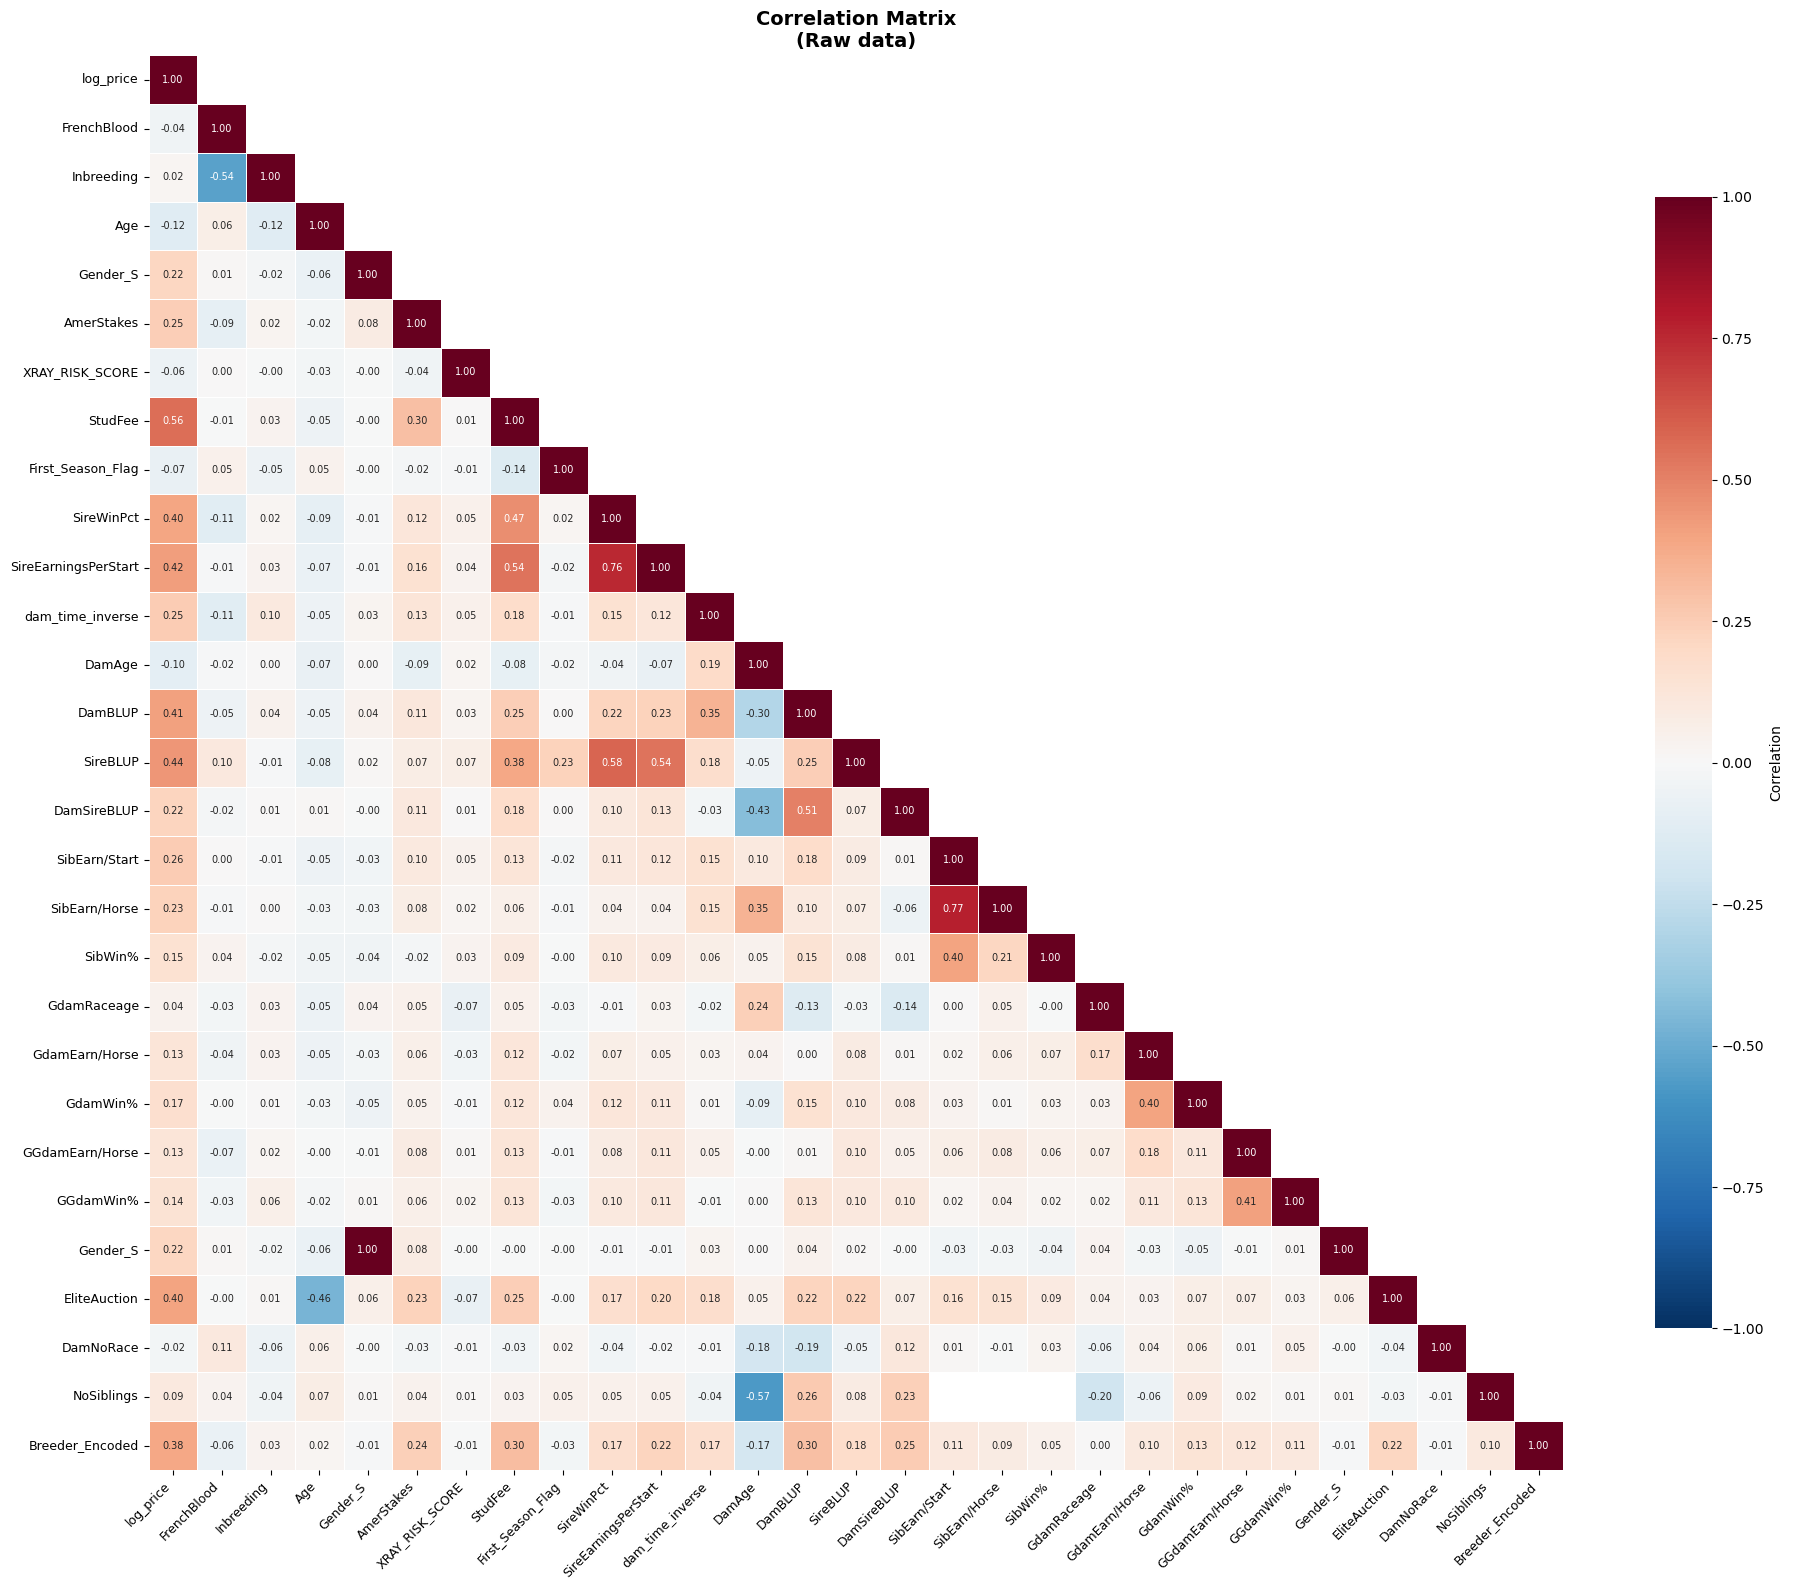


✓ Saved to correlation_heatmap_raw.svg


In [21]:
# =========================================================
# FULL CORRELATION HEATMAP
# =========================================================

print("="*70)
print("FULL CORRELATION HEATMAP")
print("="*70)

# Create figure
fig, ax = plt.subplots(figsize=(20, 16))

# Create heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
    ax=ax
)

ax.set_title('Correlation Matrix\n(Raw data)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.savefig('correlation_heatmap_raw.svg', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved to correlation_heatmap_raw.svg")


CORRELATION WITH TARGET (log_price)

[TOP POSITIVE CORRELATIONS WITH log_price]
Price                   0.784721
StudFee                 0.559000
SireBLUP                0.439898
SireEarningsPerStart    0.419177
DamBLUP                 0.411089
SireWinPct              0.397243
dam_time_inverse        0.251252
AmerStakes              0.245547
DamSireBLUP             0.222582
Gender_S                0.215407
DamEarn                 0.212312
SibEarn                 0.187227
Dam 1st                 0.165781
GdamEarn                0.144626
Sib1st                  0.121165

[TOP NEGATIVE CORRELATIONS WITH log_price]
Surgery Certificate    0.024645
Inbreeding             0.021533
FrenchBlood           -0.040128
OCD_XRAY              -0.040280
XRAY_RISK_SCORE       -0.061661
First_Season_Flag     -0.074426
DamAge                -0.080771
Surgery Severity      -0.115348
Age                   -0.120920
DamBest               -0.224610


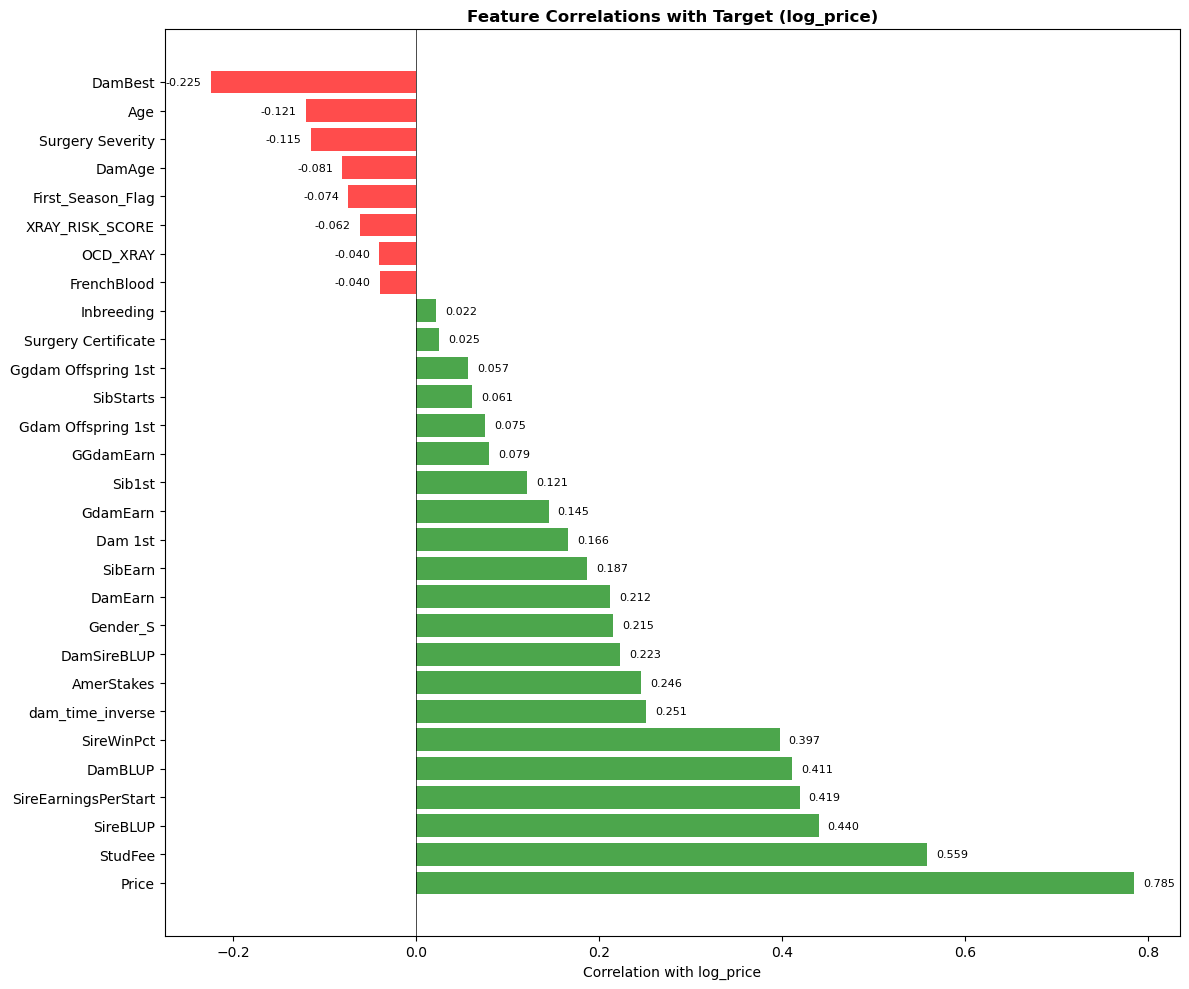


✓ Saved to correlation_with_target.png


In [13]:
# =========================================================
# CORRELATION WITH TARGET (log_price)
# =========================================================

print("="*70)
print("CORRELATION WITH TARGET (log_price)")
print("="*70)

# Get correlations with log_price
target_corr = corr_matrix["log_price"].drop("log_price").sort_values(ascending=False)

print("\n[TOP POSITIVE CORRELATIONS WITH log_price]")
print(target_corr.head(15).to_string())

print("\n[TOP NEGATIVE CORRELATIONS WITH log_price]")
print(target_corr.tail(10).to_string())

# ---------------------------------------------------------
# Bar chart of correlations with target
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

colors = ['green' if x > 0 else 'red' for x in target_corr.values]
bars = ax.barh(range(len(target_corr)), target_corr.values, color=colors, alpha=0.7)

ax.set_yticks(range(len(target_corr)))
ax.set_yticklabels(target_corr.index)
ax.set_xlabel('Correlation with log_price')
ax.set_title('Feature Correlations with Target (log_price)', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, target_corr.values)):
    ax.text(val + 0.01 if val > 0 else val - 0.01, i, f'{val:.3f}', 
            va='center', ha='left' if val > 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('correlation_with_target.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved to correlation_with_target.png")


In [15]:
# =========================================================
# HIGH CORRELATION PAIRS (Multicollinearity Check)
# =========================================================

print("="*70)
print("HIGH CORRELATION PAIRS (MULTICOLLINEARITY)")
print("="*70)

# Find highly correlated feature pairs (excluding self-correlation)
threshold = 0.7

print(f"\n[FEATURE PAIRS WITH |correlation| > {threshold}]")
print(f"{'Feature 1':<25} {'Feature 2':<25} {'Correlation':<12}")
print(f"{'-'*25} {'-'*25} {'-'*12}")

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        corr_val = corr_matrix.iloc[i, j]
        
        if abs(corr_val) > threshold and col1 != "log_price" and col2 != "log_price" and col1 != "Price" and col2 != "Price":
            high_corr_pairs.append((col1, col2, corr_val))
            print(f"{col1:<25} {col2:<25} {corr_val:+.3f}")

if not high_corr_pairs:
    print("  No highly correlated pairs found")

# ---------------------------------------------------------
# Interpretation
# ---------------------------------------------------------
print(f"\n[INTERPRETATION]")
print(f"""
High correlations between features (multicollinearity) can:
  - Make coefficients unstable in linear models (GAM)
  - Usually not a problem for tree-based models (RF, XGBoost)
  - Indicate redundant features

Common high correlations in this data:
  - SibEarn vs SibEarn/Horse (derived from same source)
  - DamStarts vs DamEarn (more starts = more chances to earn)
  - BLUP values may correlate (genetic relationships)
""")


HIGH CORRELATION PAIRS (MULTICOLLINEARITY)

[FEATURE PAIRS WITH |correlation| > 0.7]
Feature 1                 Feature 2                 Correlation 
------------------------- ------------------------- ------------
Surgery Severity          XRAY_RISK_SCORE           +0.938
OCD_XRAY                  XRAY_RISK_SCORE           +0.941
SireWinPct                SireEarningsPerStart      +0.755
DamBest                   dam_time_inverse          -0.973
SibEarn                   SibStarts                 +0.765
SibEarn                   Sib1st                    +0.840
SibStarts                 Sib1st                    +0.904
GdamEarn                  Gdam Offspring 1st        +0.794

[INTERPRETATION]

High correlations between features (multicollinearity) can:
  - Make coefficients unstable in linear models (GAM)
  - Usually not a problem for tree-based models (RF, XGBoost)
  - Indicate redundant features

Common high correlations in this data:
  - SibEarn vs SibEarn/Horse (derived from sam

In [17]:
# =========================================================
# SUMMARY TABLE
# =========================================================

print("="*70)
print("CORRELATION SUMMARY")
print("="*70)

# Create summary dataframe
summary_data = []

for feat in corr_matrix.columns:
    if feat not in ['log_price', 'Price']:
        corr_with_target = corr_matrix.loc['log_price', feat]
        abs_corr = abs(corr_with_target)
        
        # Strength category
        if abs_corr >= 0.5:
            strength = "Strong"
        elif abs_corr >= 0.3:
            strength = "Moderate"
        elif abs_corr >= 0.1:
            strength = "Weak"
        else:
            strength = "Very Weak"
        
        summary_data.append({
            'Feature': feat,
            'Correlation': corr_with_target,
            '|Correlation|': abs_corr,
            'Strength': strength,
            'Direction': 'Positive' if corr_with_target > 0 else 'Negative'
        })

summary_df = pd.DataFrame(summary_data).sort_values('|Correlation|', ascending=False)

print("\n[FULL CORRELATION SUMMARY]")
print(summary_df.to_string(index=False))

# Export
summary_df.to_excel("correlation_summary.xlsx", index=False)
print("\n✓ Saved to correlation_summary.xlsx")

# ---------------------------------------------------------
# Key insights
# ---------------------------------------------------------
print(f"\n{'='*70}")
print("KEY INSIGHTS")
print(f"{'='*70}")

strong = summary_df[summary_df['Strength'] == 'Strong']
moderate = summary_df[summary_df['Strength'] == 'Moderate']

print(f"\n[STRONG CORRELATIONS (|r| >= 0.5)]")
if len(strong) > 0:
    for _, row in strong.iterrows():
        print(f"  {row['Feature']}: {row['Correlation']:+.3f}")
else:
    print("  None")

print(f"\n[MODERATE CORRELATIONS (0.3 <= |r| < 0.5)]")
if len(moderate) > 0:
    for _, row in moderate.iterrows():
        print(f"  {row['Feature']}: {row['Correlation']:+.3f}")
else:
    print("  None")

print(f"\n[NEGATIVE CORRELATIONS (unexpected?)]")
negative = summary_df[summary_df['Correlation'] < -0.1]
for _, row in negative.iterrows():
    print(f"  {row['Feature']}: {row['Correlation']:+.3f}")


CORRELATION SUMMARY

[FULL CORRELATION SUMMARY]
             Feature  Correlation  |Correlation|  Strength Direction
             StudFee     0.559000       0.559000    Strong  Positive
            SireBLUP     0.439898       0.439898  Moderate  Positive
SireEarningsPerStart     0.419177       0.419177  Moderate  Positive
             DamBLUP     0.411089       0.411089  Moderate  Positive
          SireWinPct     0.397243       0.397243  Moderate  Positive
    dam_time_inverse     0.251252       0.251252      Weak  Positive
          AmerStakes     0.245547       0.245547      Weak  Positive
             DamBest    -0.224610       0.224610      Weak  Negative
         DamSireBLUP     0.222582       0.222582      Weak  Positive
            Gender_S     0.215407       0.215407      Weak  Positive
             DamEarn     0.212312       0.212312      Weak  Positive
             SibEarn     0.187227       0.187227      Weak  Positive
             Dam 1st     0.165781       0.165781      W

In [19]:
# =========================================================
# CORRELATION HEATMAP - ALL FEATURES
# =========================================================

print("="*70)
print("CORRELATION ANALYSIS")
print("="*70)

# ---------------------------------------------------------
# Select features for correlation analysis
# ---------------------------------------------------------
CORR_FEATURES = [
    # TARGET (first!)
    #"log_price",
    col_price,
    
    # Core
    "French Blood",
    "Inbreeding",
     col_age,
    "Gender_S", 
    col_american_stakes,
  #  col_surgery_report,
  #  col_surgery_severity,
  #  col_xray_status,
  #  col_xray_remains,
    "XRAY_RISK_SCORE",

      #Sire Features
    col_studfee,
    col_sire_first_season,
    "SireWinPct",
   # "SireEarningsPerStart",
    
    # Dam
   # col_dam_earnings,
   # col_dam_best,
   # col_dam_1st,
    'dam_time_inverse',
    #col_dam_starts,
    "DamWinPct",
    "DamEarningsPerStart",
    col_dam_age,
    
    # BLUP
    col_dam_blup,
    col_sire_blup,
    col_dam_sire_blup,
    
    # Siblings
  #  "Sibling Earnings",
  #  "Sibling Starts",
  #  "Sibling 1st",
    #col_siblings_raceage,
    "SiblingEarningsPerStart",
    "SiblingEarningsPerHorse",
    "SiblingWinPct",
    
    # Granddam
    #"Gdam  Earnings",
    #"Gdam Offspring 1st",

   # "Gdam Raceage",
    "GranddamEarningsPerHorse",
    "GranddamWinPct",
    
   # # Great-granddam
   # "Ggdam Earnings",
   # "Ggdam Offspring 1st",
    "GD_Dam_EarningsPerHorse",
    "GD_Dam_WinPct",
    
    # Binary
  #  "Gender_S",
    "Selective_Auctions",
    "Dam_Never_Raced",
    "Siblings_Missing",

    # BREEDER (smoothed target encoded)
    "Breeder_Encoded",   # <-- ADD THIS

]


# Add BLUP missing indicators if BLUP columns exist
if col_dam_blup and col_dam_blup in df.columns:
    CORR_FEATURES.append("Dam_BLUP_Missing")
if col_sire_blup and col_sire_blup in df.columns:
    CORR_FEATURES.append("Sire_BLUP_Missing")
if col_dam_sire_blup and col_dam_sire_blup in df.columns:
    CORR_FEATURES.append("Dam_Sire_BLUP_Missing")
# Filter to existing columns
CORR_FEATURES = [f for f in CORR_FEATURES if f and f in df.columns]
print(f"\nAnalyzing {len(CORR_FEATURES)} features")

# Create correlation dataframe
df_corr = df[CORR_FEATURES].copy()

# Shorten column names for display
name_map = {
    col_price: "Price",
    col_studfee: "StudFee",
    col_dam_earnings: "DamEarn",
    col_dam_best: "DamBest",
    col_dam_starts: "DamStarts",
    col_dam_age: "DamAge",
    col_age: "Age",
    col_siblings_raceage: "SibRaceage",
    col_dam_blup: "DamBLUP",
    col_sire_blup: "SireBLUP",
    col_dam_sire_blup: "DamSireBLUP",
    col_american_stakes: "AmerStakes",
    "Sibling Earnings": "SibEarn",
    "Sibling Starts": "SibStarts",
    "Sibling 1st": "Sib1st",
    "SiblingEarningsPerStart": "SibEarn/Start",
    "SiblingEarningsPerHorse": "SibEarn/Horse",
    "SiblingWinPct": "SibWin%",
    "Gdam  Earnings": "GdamEarn",
    "Gdam Raceage": "GdamRaceage",
    "GranddamEarningsPerHorse": "GdamEarn/Horse",
    "GranddamWinPct": "GdamWin%",
    "Ggdam Earnings": "GGdamEarn",
    "GD_Dam_EarningsPerHorse": "GGdamEarn/Horse",
    "GD_Dam_WinPct": "GGdamWin%",
    "French Blood": "FrenchBlood",
    "Selective_Auctions": "EliteAuction",
    "Dam_Never_Raced": "DamNoRace",
    "Siblings_Missing": "NoSiblings",
    "Dam_BLUP_Missing": "Dam_BLUP_Missing",
    "Sire_BLUP_Missing": "Sire_BLUP_Missing",
    "Dam_Sire_BLUP_Missing": "Dam_Sire_BLUP_Missing",
}


# ---------------------------------------------------------
# Calculate correlation matrix
# ---------------------------------------------------------
corr_matrix = df_corr.corr()

print(f"\n[CORRELATION MATRIX SHAPE] {corr_matrix.shape}")

CORRELATION ANALYSIS

Analyzing 30 features

[CORRELATION MATRIX SHAPE] (30, 30)


FULL CORRELATION HEATMAP


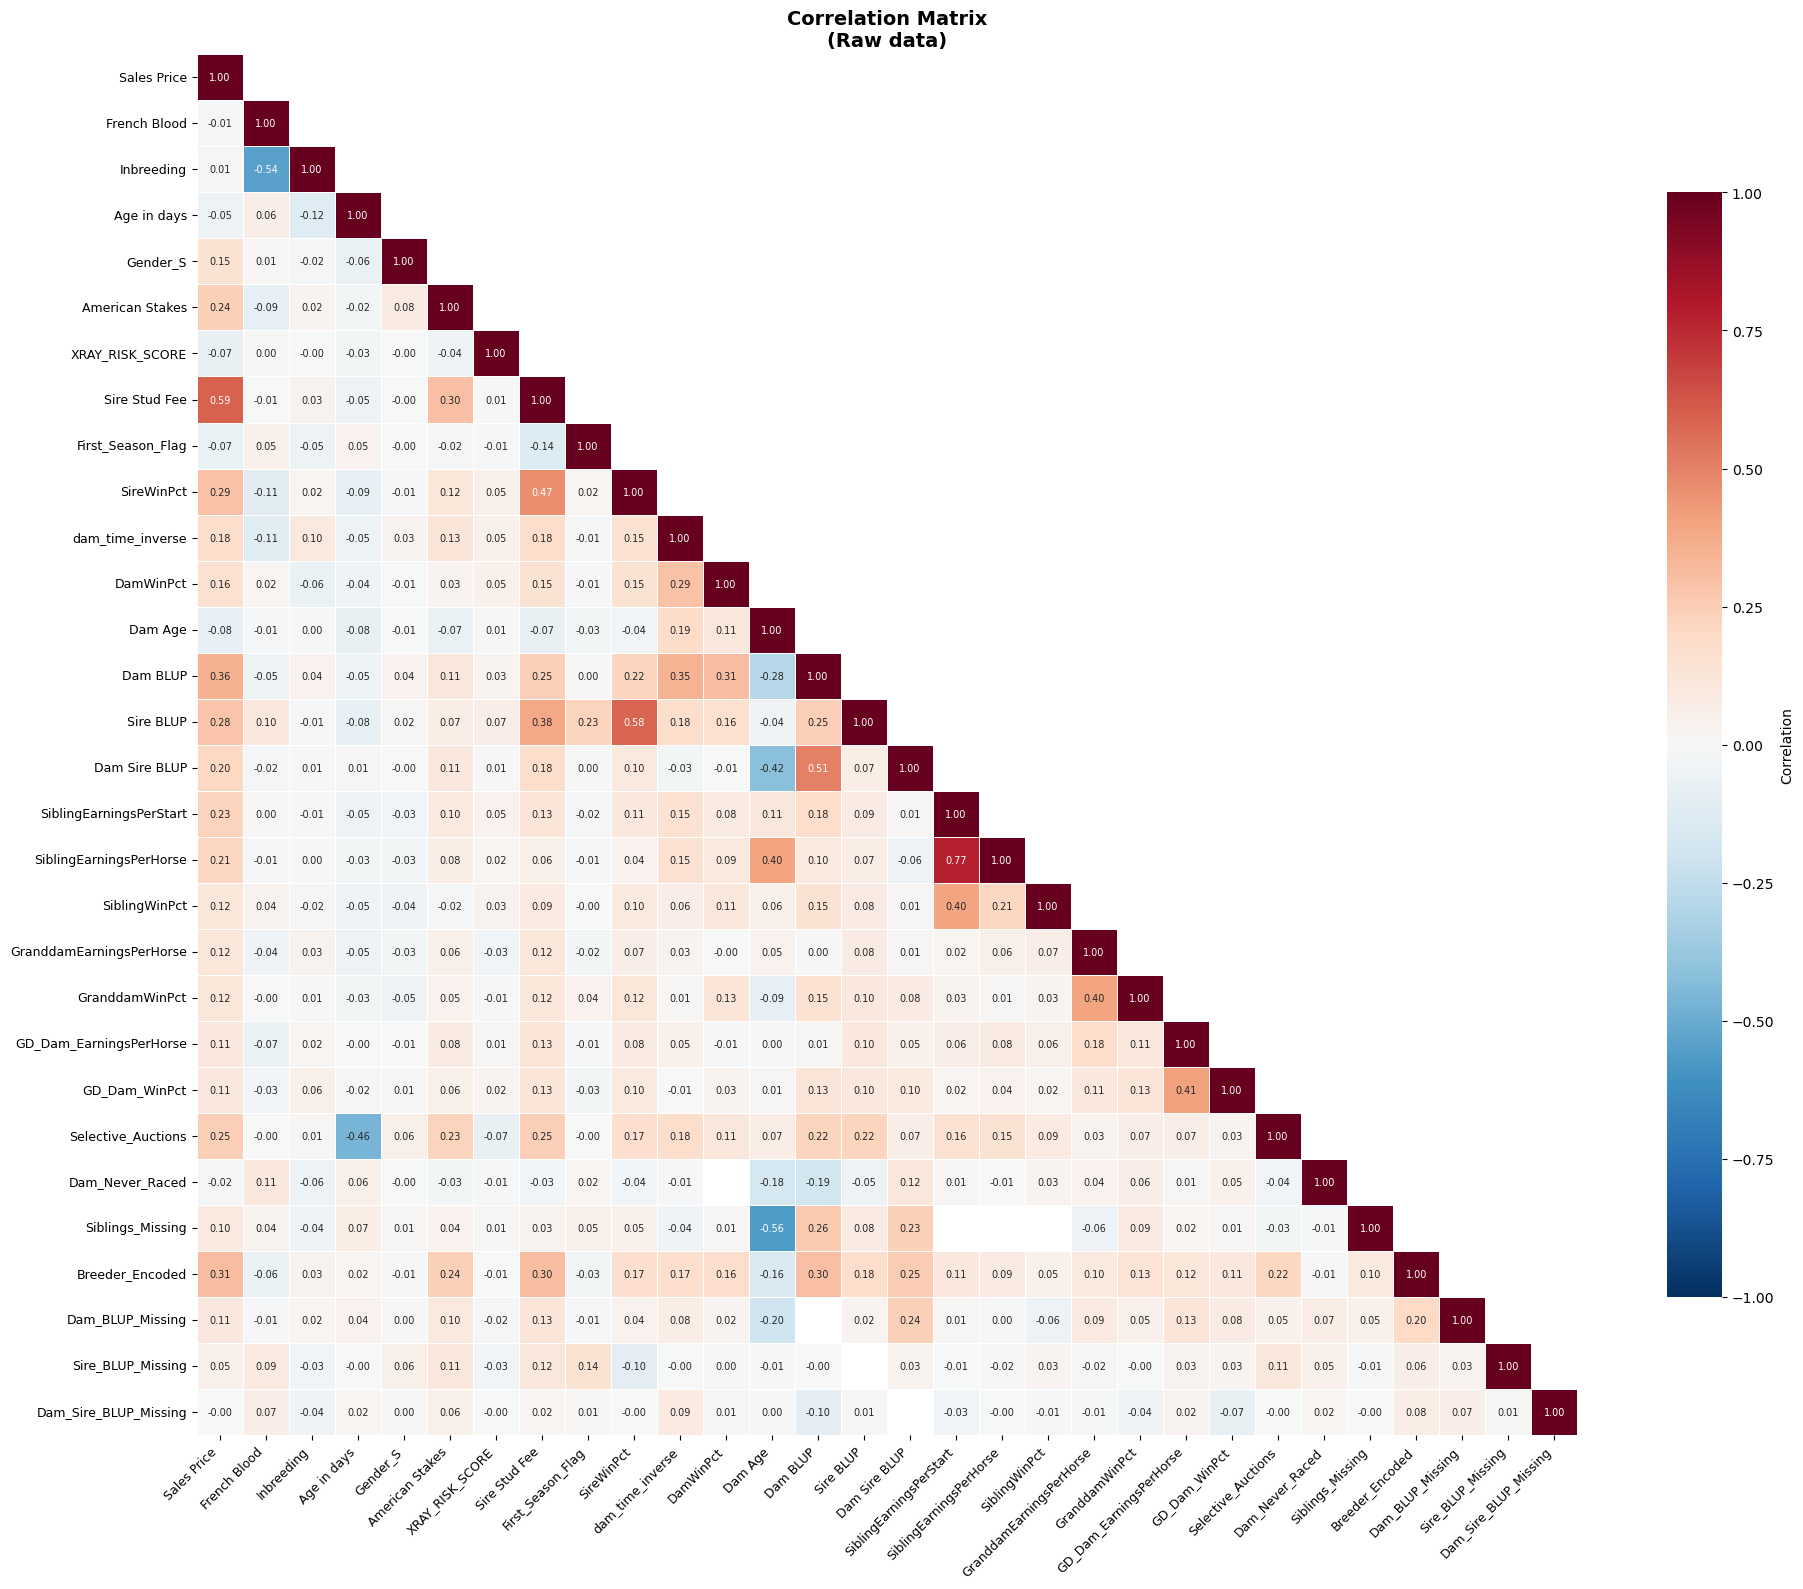


✓ Saved to correlation_heatmap_eng.svg


In [21]:
# =========================================================
# FULL CORRELATION HEATMAP
# =========================================================

print("="*70)
print("FULL CORRELATION HEATMAP")
print("="*70)

# Create figure
fig, ax = plt.subplots(figsize=(20, 16))

# Create heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
    ax=ax
)

ax.set_title('Correlation Matrix\n(Raw data)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.savefig('correlation_heatmap_eng.svg', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved to correlation_heatmap_eng.svg")